## Learning Objective
- Functions for Data cleaning
  - Invalid value identification and treatment

## Import required libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## Load the dataset

In [ ]:
#df = pd.read_csv('app.csv')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/app.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,App,Rating,Reviews,Type,Price,Content Rating
0,Photo Editor & Candy Camera & Grid & ScrapBook,4.1,159,Free,0,Everyone
1,Coloring book moana,3.9,967,Free,0,Everyone
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",4.7,87510,Free,0,Everyone
3,Sketch - Draw & Paint,4.5,215644,Free,0,Teen
4,Pixel Draw - Number Art Coloring Book,4.3,967,Free,0,Everyone


## Data Cleaning

### Let's analyse Price column 

In [ ]:
# create a copy of the dataframe
df1 = df.copy()

In [ ]:
df1['Price'].value_counts()

0          8715
$2.99       114
$0.99       106
$4.99        70
$1.99        59
           ... 
$1.29         1
$299.99       1
$379.99       1
$37.99        1
$1.20         1
Name: Price, Length: 73, dtype: int64

In [ ]:
# Lets check the datatype of the column 'price'
df1['Price'].dtype

dtype('O')

- We can see that the Price column datatype is 'object'. The Price column should be of numerical datatype, due to the presence of the "$" symbol in the Price column it is categorized into object datatype. 
- Lets clean the data in column Price and convert it into suitable datatype.

### Replace $ with space

In [ ]:
df1['Price'] = df1['Price'].str.replace('$', '')

convert column to numeric, dropping non numeric values

In [ ]:
#convert column to numeric, dropping non numeric values
df1['Price'] = pd.to_numeric(df1['Price'], errors = 'coerce')

In [ ]:
df1['Price'].value_counts()

0.00      8715
2.99       114
0.99       106
4.99        70
1.99        59
          ... 
1.29         1
299.99       1
379.99       1
37.99        1
1.20         1
Name: Price, Length: 73, dtype: int64

In [ ]:
df1['Price'].dtype

dtype('float64')

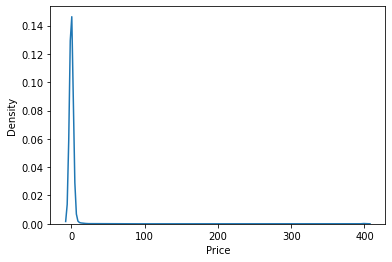

In [ ]:
## Lets analyse the Price column post cleaning 
sns.kdeplot(df1['Price'])
plt.show()

- As we know most of the apps are free version, the price for those are 0.
- Hence we can observe it from the graph that the distribution of the price is peaked at 0.
------

### df.set_index(): used to set existing column of a dataframe as dataframe index.

In [ ]:
df.drop_duplicates('App',inplace=True)

In [ ]:
## Check the shape of the dataframe after dropping duplicates
df.shape

(8190, 6)

In [ ]:
## Check the unique entries of App names
df['App'].nunique()

8190

In [ ]:
## Lets set the 'App' column as the dataframe using set_index() function.
df = df.set_index('App')

In [ ]:
## We have successfully setted the App names as the index of the dataframe.
df.head()

,Rating,Reviews,Type,Price,Content Rating
App,,,,,
Photo Editor & Candy Camera & Grid & ScrapBook,4.1,159,Free,0,Everyone
Coloring book moana,3.9,967,Free,0,Everyone
"U Launcher Lite – FREE Live Cool Themes, Hide Apps",4.7,87510,Free,0,Everyone
Sketch - Draw & Paint,4.5,215644,Free,0,Teen
Pixel Draw - Number Art Coloring Book,4.3,967,Free,0,Everyone


-------
## Happy learning:)
-------